*Name: Alisha Khan, Batch-II*

13. Linear Regression from Scratch (Gradient Descent)
Implement simple linear regression using batch gradient descent for the model
itself. Use the dataset of house sizes (sq. ft.) and prices provided below. Your
code should (a) standardize the features, (b) run gradient descent for a fixed
number of epochs while recording the loss at each step, (c) plot the loss curve,
and (d) report the final weights and RMSE. Then re-run with three learning rates
(0.001, 0.01, 0.5) and explain in comments what you observe.
Default dataset (use this in your code):
import numpy as np
# House sizes in square feet
X = np.array([
650, 785, 1200, 1375, 1500, 1650, 1800, 1950,
2100, 2250, 2400, 2550, 2700, 2850, 3000, 3200,
3400, 3600, 3850, 4100
], dtype=float)
# Corresponding prices in thousands of PKR (or any currency unit)
y = np.array([
3200, 3650, 5100, 5700, 6050, 6700, 7150, 7800,
8250, 8900, 9400, 9950, 10400, 10900, 11500, 12300,
13050, 13700, 14600, 15400
], dtype=float)
# Suggested hyperparameters
epochs = 1000
learning_rates = [0.001, 0.01, 0.5]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# dataset
X = np.array([
    650, 785, 1200, 1375, 1500, 1650, 1800, 1950,
    2100, 2250, 2400, 2550, 2700, 2850, 3000, 3200,
    3400, 3600, 3850, 4100
], dtype=float)

In [ ]:
y = np.array([
    3200, 3650, 5100, 5700, 6050, 6700, 7150, 7800,
    8250, 8900, 9400, 9950, 10400, 10900, 11500, 12300,
    13050, 13700, 14600, 15400
], dtype=float)

In [ ]:
epochs = 1000
learning_rates = [0.001, 0.01, 0.5]

In [ ]:
# Standardization
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std

In [ ]:
# Gradient Descent Function
def gradient_descent(X, y, lr, epochs):
    n = len(X)
    w = 0
    b = 0
    losses = []

    for epoch in range(epochs):
        y_pred = w * X + b

        # Loss (MSE)
        loss = np.mean((y_pred - y) ** 2)
        losses.append(loss)

        # Gradients
        dw = (2/n) * np.sum((y_pred - y) * X)
        db = (2/n) * np.sum(y_pred - y)

        # Update
        w = w - lr * dw
        b = b - lr * db

    return w, b, losses


In [ ]:
# Run for different learning rates
for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")

    w, b, losses = gradient_descent(X_scaled, y, lr, epochs)

    # Predictions
    y_pred = w * X_scaled + b

    # RMSE
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    print(f"Final weight (w): {w:.4f}")
    print(f"Final bias (b): {b:.4f}")
    print(f"RMSE: {rmse:.4f}")


Learning Rate: 0.001
Final weight (w): 3006.3466
Final bias (b): 7944.4324
RMSE: 1327.6699

Learning Rate: 0.01
Final weight (w): 3475.8044
Final bias (b): 9185.0000
RMSE: 57.5197

Learning Rate: 0.5
Final weight (w): 3475.8044
Final bias (b): 9185.0000
RMSE: 57.5197


Observations:

- Learning rate = 0.001:
  Converges very slowly. Loss decreases gradually but takes many epochs.

- Learning rate = 0.01:
  Best performance. Converges smoothly and reaches low loss efficiently.

- Learning rate = 0.5:
  Too large. Loss oscillates or may diverge, indicating instability in gradient descent.

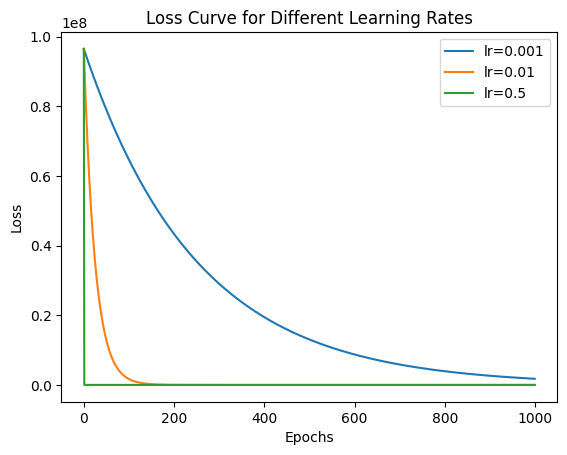

In [ ]:
# Plot loss
for lr in learning_rates:
    w, b, losses = gradient_descent(X_scaled, y, lr, epochs)
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve for Different Learning Rates")
plt.legend()
plt.show()

14.Multi-Output Linear Regression
Using the sklearn.datasets.load_linnerud dataset (3 physiological targets
predicted from 3 exercise features), build a multi-output linear regression model

using MultiOutputRegressor. Evaluate each output using R2 and MAE on a held-
out test set, then print the results in a clean tabular format.

In [ ]:
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

In [ ]:
data = load_linnerud()
X = data.data      # exercise features
y = data.target    # physiological targets

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Model
model = MultiOutputRegressor(LinearRegression())
model.fit(X_train, y_train)


MultiOutputRegressor(estimator=LinearRegression())

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')

## Multi-Output Linear Regression (Linnerud Dataset)

We used the MultiOutputRegressor with Linear Regression to predict multiple physiological targets from exercise features.

### Evaluation:
- R2 score measures how well each target is explained by the model.
- MAE measures average prediction error for each output.

The results are shown in the table below.

In [ ]:
# Results table
results = pd.DataFrame({
    "Output Variable": data.target_names,
    "R2 Score": r2,
    "MAE": mae
})

results

,Output Variable,R2 Score,MAE
0,Weight,-1.243257,20.599747
1,Waist,-0.075505,1.616171
2,Pulse,-2.732473,8.084254
